Testing the 1/GCD Collapse Hypothesis

[ Base: 8 ]
------------------------------------------------------------
Divisor d= 2 | GCD(8,2)= 2 | Neighbor Collapse: True  (Steps:  1) | Divisor Collapse: False (Steps: -1)
Divisor d= 4 | GCD(8,4)= 4 | Neighbor Collapse: True  (Steps:  2) | Divisor Collapse: False (Steps: -1)

Plotting dynamics for Base 8 (Neighbor Coupling)...


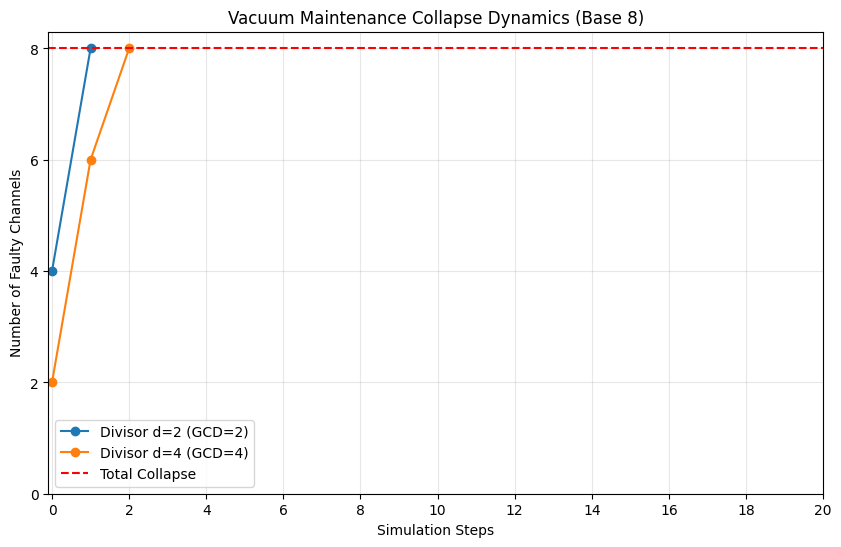


[ Base: 12 ]
------------------------------------------------------------
Divisor d= 2 | GCD(12,2)= 2 | Neighbor Collapse: True  (Steps:  1) | Divisor Collapse: False (Steps: -1)
Divisor d= 3 | GCD(12,3)= 3 | Neighbor Collapse: True  (Steps:  1) | Divisor Collapse: False (Steps: -1)
Divisor d= 4 | GCD(12,4)= 4 | Neighbor Collapse: True  (Steps:  2) | Divisor Collapse: False (Steps: -1)
Divisor d= 6 | GCD(12,6)= 6 | Neighbor Collapse: True  (Steps:  3) | Divisor Collapse: False (Steps: -1)

Plotting dynamics for Base 12 (Neighbor Coupling)...


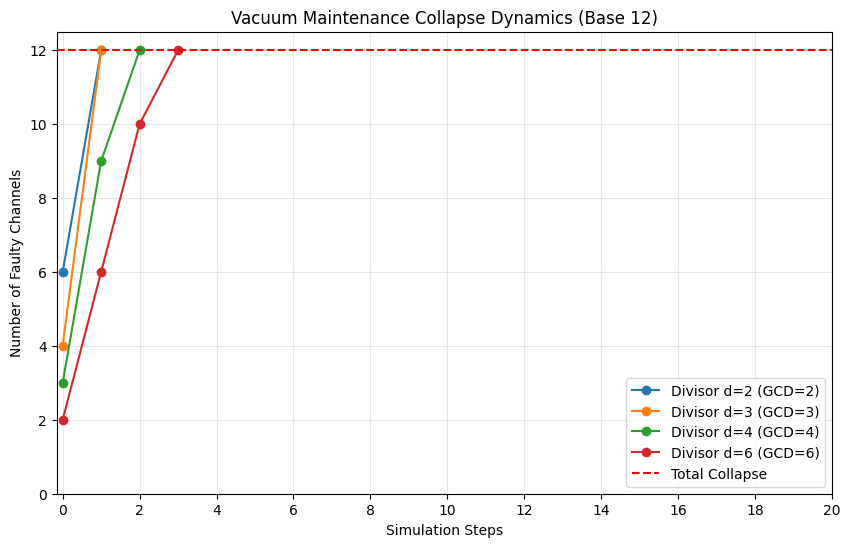

In [1]:
"""
avenue10_axis3_fano_parity_speciation_Base_Independent.py
====================================================================
AXIS 3: SPECIATION AS TOPOLOGICAL CONFINEMENT (The Fano Collapse)
Simulating Speciation via Fano Parity-Check Failure and GCD=3 Resonance
====================================================================

Key Finitist Principles:
1. Genetic states are vectors in Z_9^k (Modulo-9 alphabet).
2. Species identity is defined by a Fano-based parity-check matrix H.
3. Environmental noise introduces Modulo-9 mutations (arithmetic friction).
4. Speciation (Fano Collapse) occurs when algebraic divergence reaches
   the GCD=3 threshold, breaking the maintenance channels.

By Néstor E. Ramos
"""

import numpy as np
import matplotlib.pyplot as plt

class VacuumMaintenanceSimulator:
    def __init__(self, base, coupling_rule='neighbor'):
        """
        Initializes the vacuum maintenance simulator.

        Args:
            base (int): The base of the system (e.g., 8, 12).
            coupling_rule (str):
                - 'neighbor': Standard local verification (checks i-1 and i+1).
                - 'divisor': Verification along the divisor step (checks i-d and i+d).
        """
        self.base = base
        self.coupling_rule = coupling_rule

    def run(self, divisor, steps=20):
        """
        Runs the simulation with a divergence introduced at the given divisor.
        """
        # State: 0 = healthy, 1 = faulty/divergent
        state = np.zeros(self.base, dtype=int)

        # Introduce divergence at the divisor and its multiples (the 1/GCD failure points)
        for i in range(0, self.base, divisor):
            state[i] = 1

        history = [np.sum(state)]

        for step in range(steps):
            new_state = state.copy()
            for i in range(self.base):
                if state[i] == 0:
                    # Determine which nodes this channel verifies
                    if self.coupling_rule == 'neighbor':
                        neighbors = [(i - 1) % self.base, (i + 1) % self.base]
                    else: # 'divisor' coupling tests the GCD decomposition directly
                        neighbors = [(i - divisor) % self.base, (i + divisor) % self.base]

                    # Cascade rule: If a healthy node's verification partners are faulty,
                    # the consistency check fails, and the node collapses.
                    if any(state[n] == 1 for n in neighbors):
                        new_state[i] = 1

            state = new_state
            history.append(np.sum(state))

            # Check for total system collapse
            if np.all(state == 1):
                return {"collapsed": True, "steps_to_collapse": step + 1, "history": history}

        return {"collapsed": False, "steps_to_collapse": -1, "history": history}


def plot_collapse_dynamics(results, base):
    """Plots the collapse dynamics (number of faulty nodes over time) for a given base."""
    plt.figure(figsize=(10, 6))

    for divisor, res in results.items():
        plt.plot(res['history'], marker='o', label=f'Divisor d={divisor} (GCD={np.gcd(base, divisor)})')

    plt.title(f'Vacuum Maintenance Collapse Dynamics (Base {base})')
    plt.xlabel('Simulation Steps')
    plt.ylabel('Number of Faulty Channels')
    plt.xticks(range(0, 21, 2))
    plt.yticks(range(0, base + 1, 2 if base % 2 == 0 else 1))
    plt.axhline(y=base, color='r', linestyle='--', label='Total Collapse')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def test_gcd_hypothesis():
    # Test the specific bases and divisors mentioned in the hypothesis
    bases = [8, 12]
    divisors_map = {
        8: [2, 4],       # Non-trivial divisors of 8
        12: [2, 3, 4, 6] # Non-trivial divisors of 12
    }

    print("Testing the 1/GCD Collapse Hypothesis\n" + "="*60)

    for base in bases:
        print(f"\n[ Base: {base} ]")
        print("-" * 60)

        results_neighbor = {}
        results_divisor = {}

        for divisor in divisors_map[base]:
            # Test 1: Standard nearest-neighbor coupling
            res_n = VacuumMaintenanceSimulator(base, 'neighbor').run(divisor, steps=15)
            results_neighbor[divisor] = res_n

            # Test 2: Divisor-step coupling (tests if the system decomposes into GCD cycles)
            res_d = VacuumMaintenanceSimulator(base, 'divisor').run(divisor, steps=15)
            results_divisor[divisor] = res_d

            print(f"Divisor d={divisor:2d} | GCD({base},{divisor})={np.gcd(base, divisor):2d} | "
                  f"Neighbor Collapse: {str(res_n['collapsed']):5s} (Steps: {res_n['steps_to_collapse']:2d}) | "
                  f"Divisor Collapse: {str(res_d['collapsed']):5s} (Steps: {res_d['steps_to_collapse']:2d})")

        # Plot the results for visual verification
        print(f"\nPlotting dynamics for Base {base} (Neighbor Coupling)...")
        plot_collapse_dynamics(results_neighbor, base)


if __name__ == "__main__":
    test_gcd_hypothesis()